In [2]:
from modeller import *

env = Environ()
env.io.atom_files_directory = ['/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/']
env.io.hetatm = False
env.io.water = False

aln = Alignment(env)

# Carrega o template a partir do PDB
mdl = Model(env, file='merged')
aln.append_model(mdl, align_codes='merged', atom_files='merged.pdb')

# Carrega a sequência do target (seu .ali original)
aln.append(file='structures.ali', align_codes='target')

# Alinhamento estrutural (melhor que align simples)
aln.align2d(max_gap_length=50)

# Salva o novo alinhamento
aln.write(file='structures_align2d.ali', alignment_format='PIR')
aln.write(file='structures_align2d.pap', alignment_format='PAP')  


                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Linux gbi017039525 6.8.0-110-generic x86_64
Date and time of compil

In [ ]:
from modeller.automodel import *

class MyModel(AutoModel):
    def select_atoms(self):
        return Selection(self.residue_range('282:A', '332:A'))

a = MyModel(
    env,
    alnfile  = 'structures_align2d.ali',
    knowns   = 'merged',
    sequence = 'target'
)
 
a.starting_model = 1
a.ending_model   = 10
a.md_level = refine.very_slow

a.make()

chk_str_686W> Residue  281:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  282:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  333:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  334:A contains multiple C alpha atoms; only the first
     

In [ ]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join'

model_files = sorted(
    glob.glob(os.path.join(modelling_dir, '*.B9999*.pdb')))

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       628888     614.148     0.600

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       629416     614.664     0.600
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       678016     662.125     0.647
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [17]:
scores = []

for model_path in model_files:
    base_name = os.path.splitext(os.path.basename(model_path))[0]
    profile_file = os.path.join(modelling_dir, f'{base_name}.profile')
    
    #print(f'Calculando DOPE: {base_name}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    score = s.assess_dope()
    scores.append((score, base_name, profile_file))
    
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT',
                  file=profile_file,
                  normalize_profile=True,
                  smoothing_window=15)

openf___224_> Open           /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990001.pdb
readlinef__W> File: /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990001.pdb, Line: 6
              Modeller will only read the first 80 characters of this line.


Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445487     435.046     0.425

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       445563     435.120     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445734     435.287     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       446584     436.117     0.426

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       447842     437.346     0.427

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       449746     439.205     0.429

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       4

In [25]:

# Ranking final
print("\n Ranking por DOPE score (menor = melhor)")
for score, name, profile in sorted(scores[1:50]):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nMelhor modelo: {best[1]}  (DOPE: {best[0]:.2f})")
print(f"Perfil salvo em: {best[2]}")


 Ranking por DOPE score (menor = melhor)
  target.B99990038                          DOPE: -51413.15
  target.B99990007                          DOPE: -51292.83
  target.B99990011                          DOPE: -51278.55
  target.B99990017                          DOPE: -51164.42
  target.B99990004                          DOPE: -50979.79
  target.B99990013                          DOPE: -50782.29
  target.B99990048                          DOPE: -50632.11
  target.B99990037                          DOPE: -50365.67
  target.B99990009                          DOPE: -50310.85
  target.B99990014                          DOPE: -49444.02
  target.B99990010                          DOPE: -49062.74
  target.B99990024                          DOPE: -48891.68
  target.B99990019                          DOPE: -48715.64
  target.B99990018                          DOPE: -48705.13
  target.B99990040                          DOPE: -48700.72
  target.B99990036                          DOPE: -48699.3

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, '*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)
top10 = profiles_with_sum[-10:]  # pega os 10 últimos (menores DOPE)

In [52]:
top10[-1]

('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.BL00030004.profile',
 -17.1186)

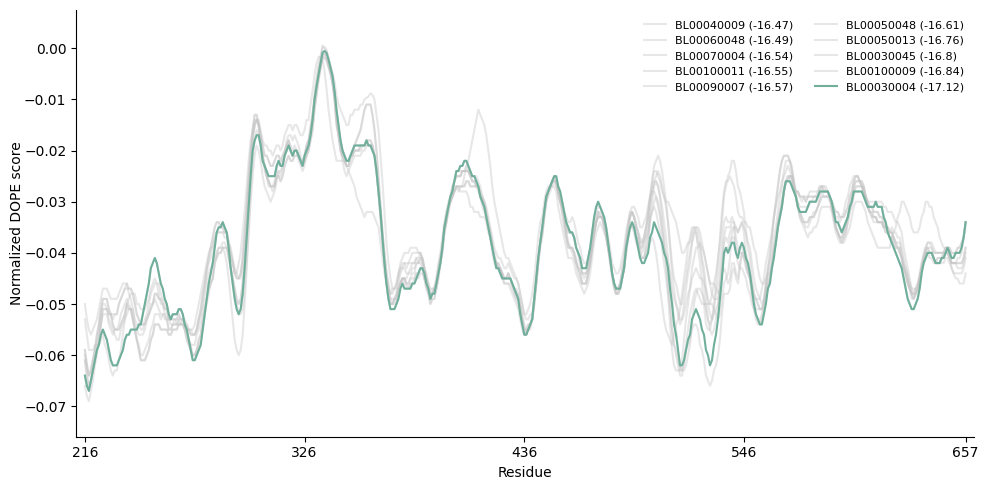

In [50]:

cinza = "#c4c4c4"
verde = '#6FAF9C'
roxo = '#A665B5'
colors = [cinza] * 9 + [verde]

plt.figure(figsize=(10, 5))

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):

    name = os.path.basename(profile_path).replace('.profile', '').replace('target.', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 215
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9:
        alpha = 1
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Residue')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.set_xlim(270, 345)
# ax.set_xticks([270, 283, 295, 310, 320, 332, 345])

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

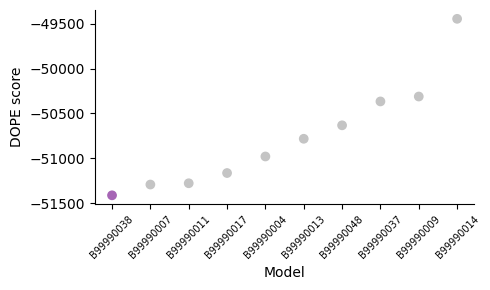

In [48]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[:10]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in top10_scores]

dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = [roxo] + [cinza] * 9

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Model')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()

In [44]:
def renumber_pdb(input_pdb, output_pdb, start):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/'

In [45]:
renumber_pdb(
        input_pdb="/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990042.pdb",
        output_pdb=modelling_dir + f"modelo_42.pdb",
        start=216
    )

In [ ]:
env = environ()
aln = alignment(env)
mdl = model(env, file='template')
aln.append_model(mdl, align_codes='template', atom_files='template.pdb')
aln.append(file='target.ali', align_codes='target')
aln.align2d()  # alinhamento baseado em estrutura, melhor que align()
aln.write(file='aln_refined.ali')